In [1]:
# download data from
# https://1drv.ms/f/c/977904c31b5ebf00/IgDZC6JRz-qiQbu0aep4c5BWAUjSlQewykyX9ke1PGZjBkY?e=hLLhFU

In [2]:
import torch
from torch.utils.data import Dataset, DataLoader
# imagefolder
from torchvision.datasets import ImageFolder
import torchvision.transforms as transforms
from tqdm import tqdm

In [3]:
# the data lives in two folders in the data\raw folder, one for each class. The folder names are the class labels.
# this script will split the data into training and test sets, and maintain the same folder structure within the train and test folders.
# automatic detection of classes should be done by ImageFolder, so we don't need to hardcode the class names.
# ensure that the raw data is never modified.

def split_data(data_dir, train_dir, test_dir, test_size):
    import os
    import shutil
    from sklearn.model_selection import train_test_split

    # Start fresh each run.
    if os.path.exists(train_dir):
        shutil.rmtree(train_dir)
    if os.path.exists(test_dir):
        shutil.rmtree(test_dir)

    os.makedirs(train_dir, exist_ok=True)
    os.makedirs(test_dir, exist_ok=True)

    # Read from raw class folders and copy files into train/test.
    for class_name in os.listdir(data_dir):
        class_path = os.path.join(data_dir, class_name)
        if not os.path.isdir(class_path):
            continue

        images = [
            f for f in os.listdir(class_path)
            if os.path.isfile(os.path.join(class_path, f))
        ]
        if not images:
            continue

        train_images, test_images = train_test_split(
            images, test_size=test_size, random_state=42
        )

        train_class_dir = os.path.join(train_dir, class_name)
        test_class_dir = os.path.join(test_dir, class_name)
        os.makedirs(train_class_dir, exist_ok=True)
        os.makedirs(test_class_dir, exist_ok=True)

        for img in train_images:
            shutil.copy2(os.path.join(class_path, img), os.path.join(train_class_dir, img))
        for img in test_images:
            shutil.copy2(os.path.join(class_path, img), os.path.join(test_class_dir, img))


split_data('data/raw', 'data/train', 'data/test', test_size=0.2)

In [4]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    # Normalize the images to have mean = 0 and std of 1 for each channel
    # transforms.Normalize(mean=[0.0, 0.0, 0.0], std=[1.0, 1.0, 1.0]),
    # transforms.RandomHorizontalFlip(p=0.5),  # randomly flip images horizontally with a probability of 0.5

])
train_dataset = ImageFolder(root=r'data\train', transform=transform)
test_dataset = ImageFolder(root=r'data\test', transform=transform)


In [5]:
# examine the dataset
print(f"Number of classes: {len(train_dataset.classes)}")
print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of test samples: {len(test_dataset)}")

# shape of the first image
print(f"Shape of the first image: {train_dataset[0][0].shape}")
print(f"Label of the first image: {train_dataset[0][1]}")
# test
print(f"Shape of the first test image: {test_dataset[0][0].shape}")
print(f"Label of the first test image: {test_dataset[0][1]}")

# class names
print(f"Class names: {train_dataset.classes}")

Number of classes: 2
Number of training samples: 160
Number of test samples: 40
Shape of the first image: torch.Size([3, 128, 128])
Label of the first image: 0
Shape of the first test image: torch.Size([3, 128, 128])
Label of the first test image: 0
Class names: ['image', 'text']


In [6]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [7]:
# pytorch model, binary classification, 2 classes, screenshots of images and screenshots of text

class ImgTxtClassifier(torch.nn.Module):
    def __init__(self):
        super(ImgTxtClassifier, self).__init__()
        self.conv1 = torch.nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1)
        self.pool = torch.nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        self.conv2 = torch.nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)
        self.fc1 = torch.nn.Linear(32 * 32 * 32, 128)
        self.fc2 = torch.nn.Linear(128, 2)  # binary classification

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(-1, 32 * 32 * 32)  # flatten
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = ImgTxtClassifier()
criterion = torch.nn.CrossEntropyLoss()  # for binary classification with 2 output neurons
optimizer = torch.optim.Adam(model.parameters(), lr=0.003) #, weight_decay=3e-3)  # L2 regularization
train_losses = []
test_losses = []

In [8]:

epochs = 20
for epoch in tqdm(range(epochs), desc="Training Progress (epochs)"):
    model.train()
    running_loss = 0.0
    for images, labels in tqdm(train_loader):
        optimizer.zero_grad()
        # labels = labels.float().unsqueeze(1)  # convert to float and add dimension for BCEWithLogitsLoss
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        # scheduler.step()
        running_loss += loss.item()

    train_losses.append(running_loss / len(train_loader))
    # get last learning rate from scheduler
    # print(scheduler.get_last_lr())
    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            # labels = labels.float().unsqueeze(1)  # convert to float and add dimension for BCEWithLogitsLoss
            loss = criterion(outputs, labels)
            test_loss += loss.item()

    test_losses.append(test_loss / len(test_loader))

    print(
        f"Epoch {epoch+1:2d} | "
        # f"LR={scheduler.get_last_lr()[0]:.6f} | "
        f"Train={train_losses[-1]:.4f} | "
        f"Val={test_losses[-1]:.4f}"
    )

Training Progress (epochs):   5%|▌         | 1/20 [00:09<02:59,  9.47s/it]

Epoch  1 | Train=3.1550 | Val=0.5251


Training Progress (epochs):  10%|█         | 2/20 [00:13<01:57,  6.54s/it]

Epoch  2 | Train=0.6287 | Val=0.5202


Training Progress (epochs):  15%|█▌        | 3/20 [00:18<01:34,  5.55s/it]

...

Epoch 18 | Train=0.1552 | Val=0.1702


Training Progress (epochs):  95%|█████████▌| 19/20 [01:30<00:04,  4.47s/it]

Epoch 19 | Train=0.1437 | Val=0.1899


Training Progress (epochs): 100%|██████████| 20/20 [01:34<00:00,  4.72s/it]

Epoch 20 | Train=0.1285 | Val=0.1504


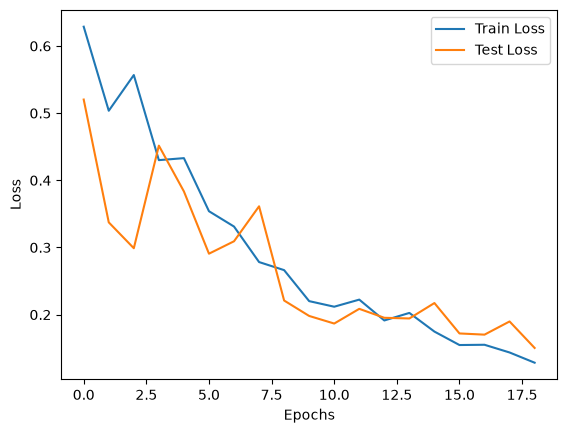

In [23]:
import matplotlib.pyplot as plt
plt.plot(train_losses[1:], label="Train Loss")
plt.plot(test_losses[1:], label="Test Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [10]:
# # accuracy
# correct = 0
# total = 0

# with torch.no_grad():
#     for images, labels in test_loader:
#         outputs = model(images)
#         predicted = torch.round(torch.sigmoid(outputs))  # convert logits to probabilities and round
#         total += labels.size(0)
#         correct += (predicted.squeeze() == labels).sum().item()

# accuracy = correct / total
# print(f"Accuracy: {accuracy:.4f}")

In [16]:
# accuracy, 2 classes, use argmax to get predicted class

correct = 0
total = 0
misclassified_images = []
with torch.no_grad():
    for images, labels in train_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)  # get the index of the max log-probability
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        # list down the predicted and actual labels for each image in the batch
        for i in range(len(labels)):
            # print(f"Predicted: {predicted[i].item()}, Actual: {labels[i].item()}")
            if predicted[i].item() != labels[i].item():
                print(f"Misclassified image index in batch: {i}")
                # name of the image in the dataset
                print(f"Image path: {train_dataset.samples[i][0]}")
                # raw logits of misclassified image
                print(f"Raw logits: {outputs[i].data}")
                misclassified_images.append((images[i], predicted[i].item(), labels[i].item(), outputs[i].data))

accuracy = correct / total
print(f"Accuracy: {accuracy:.4f}")

Misclassified image index in batch: 2
Image path: data\train\image\Screenshot 2025-08-27 101657.png
Raw logits: tensor([1.2017, 1.4013])
Misclassified image index in batch: 23
Image path: data\train\image\Screenshot 2025-11-20 165456.png
Raw logits: tensor([-1.2897,  2.6299])
Misclassified image index in batch: 7
Image path: data\train\image\Screenshot 2025-09-18 131214.png
Raw logits: tensor([0.7241, 1.8950])
Misclassified image index in batch: 25
Image path: data\train\image\Screenshot 2025-12-26 123929.png
Raw logits: tensor([-0.5504,  2.2552])
Misclassified image index in batch: 21
Image path: data\train\image\Screenshot 2025-11-11 160605.png
Raw logits: tensor([-0.9474,  2.5237])
Misclassified image index in batch: 28
Image path: data\train\image\Screenshot 2026-01-12 123032.png
Raw logits: tensor([-1.0739,  2.5842])
Accuracy: 0.9625


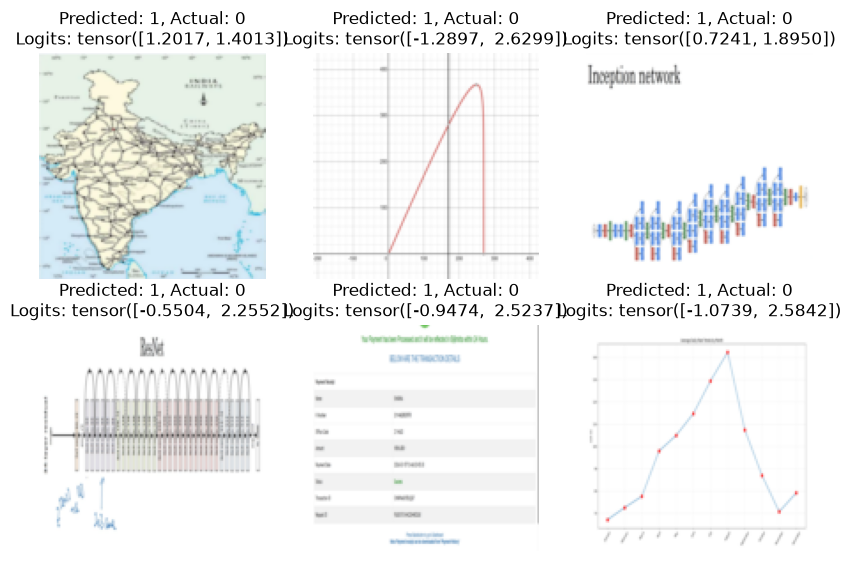

Class names: ['image', 'text']


In [17]:
# display the misclassified images with their predicted and actual labels and logits
from matplotlib import pyplot as plt

plt.figure(figsize=(10, 10))
misclassified_images = misclassified_images[:9]  # display only the first 9 misclassified images
for i, (image, predicted_label, actual_label, logits) in enumerate(misclassified_images):
    plt.subplot(3, 3, i + 1)
    plt.imshow(image.permute(1, 2, 0))  # convert from (C, H, W) to (H, W, C)
    plt.title(f"Predicted: {predicted_label}, Actual: {actual_label}\nLogits: {logits}")
    plt.axis('off')
plt.show()

# print actual label names mapped to 0 and 1
print(f"Class names: {train_dataset.classes}")

In [13]:
# save the model
torch.save(model.state_dict(), "img_txt_classifier.pth")

In [14]:
# inference

# step 1 is to load the model and the state dict
model = ImgTxtClassifier()
model.load_state_dict(torch.load("img_txt_classifier.pth"))

# step 2 is to set the model to evaluation mode
model.eval()

# path of the image to be classified
from PIL import Image
path = r"C:\Users\101119\Pictures\screenshots\Screenshot 2023-08-08 115445.png"

# step 3 is to load the image and apply the same transformations as during training
image = Image.open(path).convert("RGB")
transformed_image = transform(image).unsqueeze(0)  # add batch dimension

# step 4 is to pass the image through the model and get the predicted class
with torch.no_grad():
    output = model(transformed_image)
    _, predicted_class = torch.max(output.data, 1)
    print("Predicted class:", predicted_class.item())
    print("Predicted class name:", train_dataset.classes[predicted_class.item()])


Predicted class: 0
Predicted class name: image


In [18]:
# confusion matrix over train set and test set
from sklearn.metrics import confusion_matrix
import numpy as np

with torch.no_grad():
    # confusion matrix for train set
    y_true_train = []
    y_pred_train = []
    for images, labels in train_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        y_true_train.extend(labels.numpy())
        y_pred_train.extend(predicted.numpy())
    cm_train = confusion_matrix(y_true_train, y_pred_train)
    print("Confusion Matrix - Train Set:")
    print(cm_train)

    # confusion matrix for test set
    y_true_test = []
    y_pred_test = []
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        y_true_test.extend(labels.numpy())
        y_pred_test.extend(predicted.numpy())
    cm_test = confusion_matrix(y_true_test, y_pred_test)
    print("Confusion Matrix - Test Set:")
    print(cm_test)


Confusion Matrix - Train Set:
[[74  6]
 [ 0 80]]
Confusion Matrix - Test Set:
[[18  2]
 [ 0 20]]


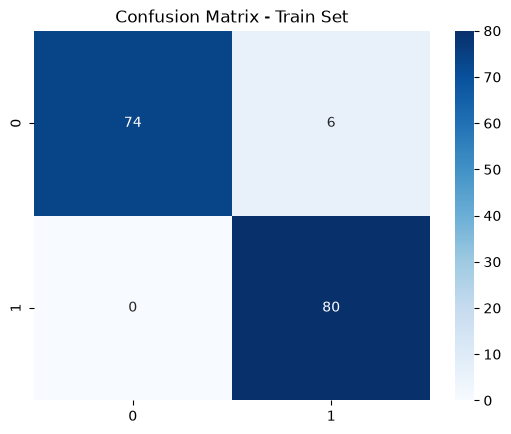

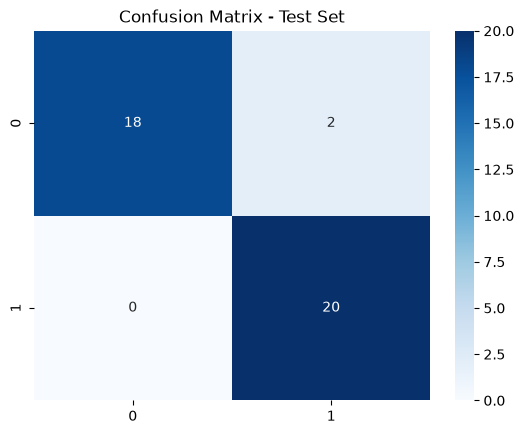

In [22]:
import seaborn as sns
# plot confusion matrix for train set
sns.heatmap(cm_train, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Train Set")
plt.show()
# plot confusion matrix for test set
sns.heatmap(cm_test, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Test Set")
plt.show()